# 015. Simple word2vec 작성

- skipgram 방식을 이용하여 window size 2 의 simplified word2vec model 작성  


- embedding layer 의 차원은 2 로 하여 시각화 가능하도록 한다

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
import numpy as np
import re

### Toy 말뭉치

In [92]:
corpus = ['King is a very strong man.', 
          'Queen is a wise and pretty woman.', 
          'Boy is a young man.',
          'Girl is a young and pretty woman.',
          'Prince is young and will be a strong and wise king.',
          'Princess is a young woman and will be a pretty and wise queen.',
          'Man is strong.', 
          'Woman is pretty.',
          'Prince is a boy will be a king.',
          'Princess is a girl will be a queen.']

In [93]:
cleaned_corpus = []
for text in corpus:
    text = re.sub(r'[^a-zA-Z ]', '', text)    #영문
    cleaned_corpus.append(text.lower())
    
cleaned_corpus

['king is a very strong man',
 'queen is a wise and pretty woman',
 'boy is a young man',
 'girl is a young and pretty woman',
 'prince is young and will be a strong and wise king',
 'princess is a young woman and will be a pretty and wise queen',
 'man is strong',
 'woman is pretty',
 'prince is a boy will be a king',
 'princess is a girl will be a queen']

### stopwords 제거

In [94]:
stop_words = ['is', 'a' ,'will', 'be', 'and']

results = []
    
for text in cleaned_corpus:
    tmp = []
    #for word in okt.morphs(text):  
    for word in text.split():
        if word not in stop_words:
            tmp.append(word)
    results.append(' '.join(tmp))

In [95]:
cleaned_corpus = results
cleaned_corpus

['king very strong man',
 'queen wise pretty woman',
 'boy young man',
 'girl young pretty woman',
 'prince young strong wise king',
 'princess young woman pretty wise queen',
 'man strong',
 'woman pretty',
 'prince boy king',
 'princess girl queen']

### vocaburary 모음 작성

In [96]:
words = []

for sentence in cleaned_corpus:
    for word in sentence.split(' '):
        words.append(word)

words = set(words)
words

{'boy',
 'girl',
 'king',
 'man',
 'pretty',
 'prince',
 'princess',
 'queen',
 'strong',
 'very',
 'wise',
 'woman',
 'young'}

### word-to-index, index-to-word 작성

- word 를 index 로 변환  

- sentence 를 word index 로 변환  

- window size 에 따라 train data 생성

In [97]:
word2index = dict((w, i) for i, w in enumerate(words))
index2word = dict((i, w) for i, w in enumerate(words))

In [98]:
index2word

{0: 'prince',
 1: 'young',
 2: 'very',
 3: 'pretty',
 4: 'wise',
 5: 'woman',
 6: 'queen',
 7: 'princess',
 8: 'man',
 9: 'king',
 10: 'boy',
 11: 'strong',
 12: 'girl'}

### skip-gram 으로 training data 생성

In [99]:
cleaned_corpus

['king very strong man',
 'queen wise pretty woman',
 'boy young man',
 'girl young pretty woman',
 'prince young strong wise king',
 'princess young woman pretty wise queen',
 'man strong',
 'woman pretty',
 'prince boy king',
 'princess girl queen']

In [100]:
sentences = []
for sentence in cleaned_corpus:
    sentences.append(sentence.split())
sentences

[['king', 'very', 'strong', 'man'],
 ['queen', 'wise', 'pretty', 'woman'],
 ['boy', 'young', 'man'],
 ['girl', 'young', 'pretty', 'woman'],
 ['prince', 'young', 'strong', 'wise', 'king'],
 ['princess', 'young', 'woman', 'pretty', 'wise', 'queen'],
 ['man', 'strong'],
 ['woman', 'pretty'],
 ['prince', 'boy', 'king'],
 ['princess', 'girl', 'queen']]

In [101]:
WINDOW_SIZE = 2

data = []
for sentence in sentences:
    for i, word in enumerate(sentence):
        for neighbor in sentence[max(i - WINDOW_SIZE, 0) : min(i + WINDOW_SIZE, len(sentence)) + 1] : 
            if neighbor != word:
                data.append([word, neighbor])

In [102]:
data[:10]

[['king', 'very'],
 ['king', 'strong'],
 ['very', 'king'],
 ['very', 'strong'],
 ['very', 'man'],
 ['strong', 'king'],
 ['strong', 'very'],
 ['strong', 'man'],
 ['man', 'very'],
 ['man', 'strong']]

In [103]:
import pandas as pd 
df = pd.DataFrame(data, columns=['input', 'label'])
df.head()

,input,label
0,king,very
1,king,strong
2,very,king
3,very,strong
4,very,man


### One hot encoding

In [104]:
from tensorflow.keras.utils import to_categorical

len(words)

13

### One hot encoding 된 train, label data

In [105]:
X = []    # input word
Y = []    # target word

for x, y in zip(df['input'], df['label']):
    X.append(to_categorical(word2index[x], len(words)))
    Y.append(to_categorical(word2index[y], len(words)))

In [106]:
X[:3]

[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=float32),
 array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)]

In [107]:
Y[:3]

[array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=float32)]

In [108]:
# convert them to numpy arrays
X_train = np.array(X)
Y_train = np.array(Y)

In [109]:
X_train.shape

(84, 13)

In [110]:
Y_train.shape

(84, 13)

**시각화를 위해 hidden layer 의 unit 을 2 로 제한**
- embedding layer : 2

In [111]:
len(words)

13

In [112]:
model = Sequential()
model.add(Dense(2, input_dim=len(words)))
model.add(Dense(len(words), activation='softmax'))

In [113]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [114]:
model.fit(X_train, Y_train, epochs=500, batch_size=3)

Epoch 1/500
28/28 [==============================] - 0s 630us/step - loss: 2.6179 - accuracy: 0.0714
Epoch 2/500
28/28 [==============================] - 0s 612us/step - loss: 2.6085 - accuracy: 0.0714
Epoch 3/500
28/28 [==============================] - 0s 605us/step - loss: 2.6009 - accuracy: 0.0714
Epoch 4/500
28/28 [==============================] - 0s 607us/step - loss: 2.5939 - accuracy: 0.0714
Epoch 5/500
28/28 [==============================] - 0s 608us/step - loss: 2.5868 - accuracy: 0.0714
Epoch 6/500
28/28 [==============================] - 0s 590us/step - loss: 2.5803 - accuracy: 0.0714
Epoch 7/500
28/28 [==============================] - 0s 585us/step - loss: 2.5739 - accuracy: 0.0714
Epoch 8/500
28/28 [==============================] - 0s 582us/step - loss: 2.5679 - accuracy: 0.0952
Epoch 9/500
28/28 [==============================] - 0s 597us/step - loss: 2.5627 - accuracy: 0.1190
Epoch 10/500
28/28 [==============================] - 0s 606us/step - loss: 2.5569 - accura

28/28 [==============================] - 0s 576us/step - loss: 2.3240 - accuracy: 0.1905
Epoch 82/500
28/28 [==============================] - 0s 584us/step - loss: 2.3202 - accuracy: 0.1905
Epoch 83/500
28/28 [==============================] - 0s 599us/step - loss: 2.3174 - accuracy: 0.2024
Epoch 84/500
28/28 [==============================] - 0s 614us/step - loss: 2.3142 - accuracy: 0.2024
Epoch 85/500
28/28 [==============================] - 0s 591us/step - loss: 2.3112 - accuracy: 0.2024
Epoch 86/500
28/28 [==============================] - 0s 589us/step - loss: 2.3082 - accuracy: 0.2024
Epoch 87/500
28/28 [==============================] - 0s 594us/step - loss: 2.3053 - accuracy: 0.2024
Epoch 88/500
28/28 [==============================] - 0s 592us/step - loss: 2.3024 - accuracy: 0.2024
Epoch 89/500
28/28 [==============================] - 0s 578us/step - loss: 2.2990 - accuracy: 0.2024
Epoch 90/500
28/28 [==============================] - 0s 593us/step - loss: 2.2960 - accuracy: 

28/28 [==============================] - 0s 605us/step - loss: 2.1323 - accuracy: 0.2262
Epoch 161/500
28/28 [==============================] - 0s 611us/step - loss: 2.1316 - accuracy: 0.2262
Epoch 162/500
28/28 [==============================] - 0s 613us/step - loss: 2.1296 - accuracy: 0.2262
Epoch 163/500
28/28 [==============================] - 0s 594us/step - loss: 2.1285 - accuracy: 0.2262
Epoch 164/500
28/28 [==============================] - 0s 581us/step - loss: 2.1271 - accuracy: 0.2262
Epoch 165/500
28/28 [==============================] - 0s 583us/step - loss: 2.1260 - accuracy: 0.2262
Epoch 166/500
28/28 [==============================] - 0s 584us/step - loss: 2.1238 - accuracy: 0.2262
Epoch 167/500
28/28 [==============================] - 0s 582us/step - loss: 2.1231 - accuracy: 0.2262
Epoch 168/500
28/28 [==============================] - 0s 590us/step - loss: 2.1216 - accuracy: 0.2262
Epoch 169/500
28/28 [==============================] - 0s 585us/step - loss: 2.1203 - a

28/28 [==============================] - 0s 601us/step - loss: 2.0529 - accuracy: 0.2738
Epoch 240/500
28/28 [==============================] - 0s 601us/step - loss: 2.0520 - accuracy: 0.2738
Epoch 241/500
28/28 [==============================] - 0s 603us/step - loss: 2.0517 - accuracy: 0.2738
Epoch 242/500
28/28 [==============================] - 0s 582us/step - loss: 2.0511 - accuracy: 0.2738
Epoch 243/500
28/28 [==============================] - 0s 578us/step - loss: 2.0502 - accuracy: 0.2738
Epoch 244/500
28/28 [==============================] - 0s 585us/step - loss: 2.0495 - accuracy: 0.2738
Epoch 245/500
28/28 [==============================] - 0s 610us/step - loss: 2.0486 - accuracy: 0.2738
Epoch 246/500
28/28 [==============================] - 0s 577us/step - loss: 2.0478 - accuracy: 0.2738
Epoch 247/500
28/28 [==============================] - 0s 579us/step - loss: 2.0473 - accuracy: 0.2738
Epoch 248/500
28/28 [==============================] - 0s 566us/step - loss: 2.0465 - a

28/28 [==============================] - 0s 601us/step - loss: 2.0022 - accuracy: 0.2738
Epoch 319/500
28/28 [==============================] - 0s 605us/step - loss: 2.0023 - accuracy: 0.2738
Epoch 320/500
28/28 [==============================] - 0s 612us/step - loss: 2.0011 - accuracy: 0.2738
Epoch 321/500
28/28 [==============================] - 0s 598us/step - loss: 2.0004 - accuracy: 0.2738
Epoch 322/500
28/28 [==============================] - 0s 604us/step - loss: 1.9996 - accuracy: 0.2738
Epoch 323/500
28/28 [==============================] - 0s 609us/step - loss: 1.9995 - accuracy: 0.2738
Epoch 324/500
28/28 [==============================] - 0s 592us/step - loss: 1.9987 - accuracy: 0.2738
Epoch 325/500
28/28 [==============================] - 0s 594us/step - loss: 1.9984 - accuracy: 0.2738
Epoch 326/500
28/28 [==============================] - 0s 602us/step - loss: 1.9979 - accuracy: 0.2738
Epoch 327/500
28/28 [==============================] - 0s 592us/step - loss: 1.9978 - a

28/28 [==============================] - 0s 551us/step - loss: 1.9716 - accuracy: 0.2738
Epoch 398/500
28/28 [==============================] - 0s 547us/step - loss: 1.9704 - accuracy: 0.2738
Epoch 399/500
28/28 [==============================] - 0s 544us/step - loss: 1.9701 - accuracy: 0.2738
Epoch 400/500
28/28 [==============================] - 0s 542us/step - loss: 1.9701 - accuracy: 0.2738
Epoch 401/500
28/28 [==============================] - 0s 561us/step - loss: 1.9697 - accuracy: 0.2738
Epoch 402/500
28/28 [==============================] - 0s 551us/step - loss: 1.9695 - accuracy: 0.2738
Epoch 403/500
28/28 [==============================] - 0s 552us/step - loss: 1.9694 - accuracy: 0.2738
Epoch 404/500
28/28 [==============================] - 0s 573us/step - loss: 1.9695 - accuracy: 0.2738
Epoch 405/500
28/28 [==============================] - 0s 558us/step - loss: 1.9689 - accuracy: 0.2738
Epoch 406/500
28/28 [==============================] - 0s 569us/step - loss: 1.9679 - a

28/28 [==============================] - 0s 557us/step - loss: 1.9534 - accuracy: 0.2738
Epoch 477/500
28/28 [==============================] - 0s 554us/step - loss: 1.9536 - accuracy: 0.2619
Epoch 478/500
28/28 [==============================] - 0s 555us/step - loss: 1.9537 - accuracy: 0.2738
Epoch 479/500
28/28 [==============================] - 0s 560us/step - loss: 1.9531 - accuracy: 0.2976
Epoch 480/500
28/28 [==============================] - 0s 555us/step - loss: 1.9531 - accuracy: 0.2619
Epoch 481/500
28/28 [==============================] - 0s 554us/step - loss: 1.9529 - accuracy: 0.2738
Epoch 482/500
28/28 [==============================] - 0s 565us/step - loss: 1.9539 - accuracy: 0.2619
Epoch 483/500
28/28 [==============================] - 0s 548us/step - loss: 1.9523 - accuracy: 0.2738
Epoch 484/500
28/28 [==============================] - 0s 552us/step - loss: 1.9527 - accuracy: 0.2738
Epoch 485/500
28/28 [==============================] - 0s 563us/step - loss: 1.9525 - a

### 첫번째 Hidden Layer 추출 및 weight + bias 를 vector 로 합산

In [115]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_14 (Dense)             (None, 2)                 28        
_________________________________________________________________
dense_15 (Dense)             (None, 13)                39        
Total params: 67
Trainable params: 67
Non-trainable params: 0
_________________________________________________________________


In [116]:
model.layers[0].get_weights()

[array([[-1.0405254 ,  0.18712726],
        [-0.02629645,  0.30111936],
        [-1.9705783 , -0.8475001 ],
        [ 2.6566627 , -1.324632  ],
        [ 0.45859694,  0.51271456],
        [ 1.0112549 ,  1.3594233 ],
        [ 1.3263159 ,  1.0626643 ],
        [ 2.1040313 , -1.0193402 ],
        [-1.3820726 ,  0.6662159 ],
        [-1.2810392 ,  0.29811984],
        [-0.17775752, -2.034975  ],
        [-0.6009103 , -1.4164695 ],
        [ 1.622341  ,  1.1185884 ]], dtype=float32),
 array([0.18870018, 0.01880753], dtype=float32)]

In [117]:
model.layers[0].get_weights()[1]

array([0.18870018, 0.01880753], dtype=float32)

In [118]:
vectors= model.layers[0].get_weights()[0]

In [119]:
pd.DataFrame(vectors, columns = ['x1', 'x2'])

,x1,x2
0,-1.040525,0.187127
1,-0.026296,0.301119
2,-1.970578,-0.847500
3,2.656663,-1.324632
4,0.458597,0.512715
5,1.011255,1.359423
6,1.326316,1.062664
7,2.104031,-1.019340
8,-1.382073,0.666216
9,-1.281039,0.298120


In [120]:
w2v = pd.DataFrame(vectors, columns = ['x1', 'x2'])
w2v['word'] = words
w2v

,x1,x2,word
0,-1.040525,0.187127,prince
1,-0.026296,0.301119,young
2,-1.970578,-0.847500,very
3,2.656663,-1.324632,pretty
4,0.458597,0.512715,wise
5,1.011255,1.359423,woman
6,1.326316,1.062664,queen
7,2.104031,-1.019340,princess
8,-1.382073,0.666216,man
9,-1.281039,0.298120,king


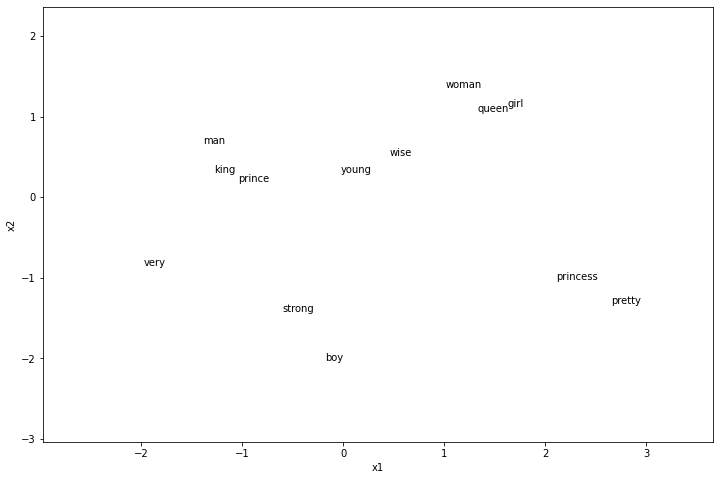

In [122]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(12,8))

for word, x1, x2 in zip(w2v['word'], w2v['x1'], w2v['x2']):
    ax.annotate(word, (x1, x2))
    
PADDING = 1.0
x_axis_min = np.min(vectors, axis=0)[0] - PADDING
y_axis_min = np.min(vectors, axis=0)[1] - PADDING
x_axis_max = np.max(vectors, axis=0)[0] + PADDING
y_axis_max = np.max(vectors, axis=0)[1] + PADDING
 
plt.xlim(x_axis_min, x_axis_max)
plt.ylim(y_axis_min, y_axis_max)
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

## Embedding Projector 와 비교

https://projector.tensorflow.org/ 